In [1]:
import zipfile
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['default', 'science'])

import statsmodels.api as sm

from code_utils.plot_figure import plot_correlation_matrix
from code_utils.stepwise_model import stepwise_MNL
from code_utils.utils_basic import PROJECT_PATH

# 1. Load data

In [2]:
def print_data_info(data):
    print('\nData info:',
        '\nData shape:', data.shape,
        '\nColumns:', data.columns.tolist(),
        '\nNA values:', data.isna().sum().sum(),)
# ==========================================================
def load_csv_from_zip(zip_path, csv_path, **kwargs):
    """
    Load a CSV file from a ZIP archive into a pandas DataFrame.
    """
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(csv_path) as f:
            df = pd.read_csv(f, **kwargs)
    return df
# ==========================================================

landuse_name = {
    'RES' : 'residential',
    'BUS' : 'business',
    'COM' : 'commercial',
    'REC' : 'recreational',
    'EDU' : 'educational',
    'OPS' : 'open_space',
    'TRS' : 'transportation',
}


In [3]:
from typing import Dict, Hashable, Optional, Sequence, Tuple, Union

import numpy as np
from numpy.typing import ArrayLike, NDArray

def downsample_data(
    feature: ArrayLike,
    labels: ArrayLike,
    centers: ArrayLike = None,
    sampling_size: Optional[int] = None,
) -> Tuple[NDArray[np.floating], NDArray[np.int_]]:
    """
    Downsample each class by keeping samples closest to the class center.

    For every unique label, this function selects `k` samples with the smallest
    Euclidean distance to that label's center (centroid). This is useful for
    balancing class counts while preserving the most "central"/typical examples.

    Parameters
    ----------
    feature : ArrayLike
        Feature matrix of shape (n_samples, n_features).
    labels : ArrayLike
        Class labels of shape (n_samples,). Any hashable labels are accepted.
        (Returned labels are encoded as integers if the input is not numeric.)
    centers : ArrayLike or dict or None, default=None
        Class centers to use for distance computation.

        Supported formats:
        - None:
            Compute each class center as the mean of its samples.
        - ArrayLike of shape (n_classes, n_features):
            Centers aligned with `np.unique(labels)` order.
        - dict[label, ArrayLike]:
            Mapping from label value to its center (shape (n_features,)).

    sampling_size : int or None, default=None
        Number of samples to keep per class.
        - If None, defaults to the minority class size (minimum count across labels).
        - If provided, `k = min(sampling_size, class_count)` is used per class.

    Returns
    -------
    feature_ds : numpy.ndarray
        Downsampled feature matrix of shape (n_selected, n_features).
    labels_ds : numpy.ndarray
        Downsampled labels of shape (n_selected,). Returned as integer codes
        corresponding to the original label values' order in `np.unique(labels)`.

    Raises
    ------
    ValueError
        If `feature` and `labels` have incompatible lengths, or if centers have
        inconsistent shapes / missing labels.

    Notes
    -----
    - Distance metric: Euclidean distance in feature space.
    - Selection rule: keep the `k` nearest samples to the center per class.
    - Output order: classes are processed in `np.unique(labels)` order; within each
      class, samples are ordered by increasing distance to the center.
    """
    X = np.asarray(feature, dtype=float)
    y_raw = np.asarray(labels)

    if X.ndim != 2:
        raise ValueError(f"`feature` must be 2D (n_samples, n_features). Got shape {X.shape}.")
    if y_raw.ndim != 1:
        raise ValueError(f"`labels` must be 1D (n_samples,). Got shape {y_raw.shape}.")
    if X.shape[0] != y_raw.shape[0]:
        raise ValueError(
            f"Mismatched lengths: feature has {X.shape[0]} samples but labels has {y_raw.shape[0]}."
        )

    # Encode labels to stable integer codes based on unique label values
    classes, y = np.unique(y_raw, return_inverse=True)
    n_classes = classes.shape[0]
    n_features = X.shape[1]

    # Determine default sampling size (minority class size)
    class_counts = np.bincount(y, minlength=n_classes)
    minority_size = int(class_counts.min()) if n_classes > 0 else 0

    if sampling_size is None:
        k_default = minority_size
    else:
        if sampling_size < 1:
            raise ValueError("sampling_size must be >= 1 when provided.")
        k_default = int(sampling_size)

    # Build centers per integer-coded class
    centers_arr = np.zeros((n_classes, n_features), dtype=float)

    if centers is None:
        # Compute mean center for each class
        for ci in range(n_classes):
            idx = np.where(y == ci)[0]
            # idx is non-empty because ci comes from unique labels
            centers_arr[ci] = X[idx].mean(axis=0)

    elif isinstance(centers, dict):
        # Dict centers: key is original label value (not encoded int)
        for ci, cval in enumerate(classes):
            if cval not in centers:
                raise ValueError(f"Missing center for label {cval!r} in `centers` dict.")
            center_vec = np.asarray(centers[cval], dtype=float)
            if center_vec.shape != (n_features,):
                raise ValueError(
                    f"Center for label {cval!r} must have shape ({n_features},), got {center_vec.shape}."
                )
            centers_arr[ci] = center_vec

    else:
        # Array-like centers aligned with np.unique(labels) order
        centers_arr = np.asarray(centers, dtype=float)
        if centers_arr.shape != (n_classes, n_features):
            raise ValueError(
                f"`centers` must have shape (n_classes, n_features) = ({n_classes}, {n_features}), "
                f"got {centers_arr.shape}."
            )

    # Select nearest samples per class
    selected_indices: list[int] = []

    for ci in range(n_classes):
        idx = np.where(y == ci)[0]
        k = min(k_default, idx.size)

        # Compute Euclidean distances to the class center
        diffs = X[idx] - centers_arr[ci]            # (n_i, n_features)
        dists = np.linalg.norm(diffs, axis=1)       # (n_i,)

        # Take k smallest distances
        order = np.argsort(dists, kind="stable")
        chosen = idx[order[:k]]

        selected_indices.extend(chosen.tolist())

    selected_indices = np.array(selected_indices, dtype=int)

    # Return downsampled arrays
    X_ds = X[selected_indices]
    y_ds = y[selected_indices].astype(int)

    return X_ds, y_ds

In [4]:
zip_path = PROJECT_PATH / 'data/dataset.zip'

# Load L-space and P-space data for comparison
data_l = (
    load_csv_from_zip(
        zip_path,
        csv_path = 'space_l_undersample.csv',
        dtype = {'pt_code' : str},
        index_col = 0,)
    .rename(columns = lambda x : x.removesuffix('_centrality'))
    .rename(columns = landuse_name)
)
data_l['label'] = data_l['label'].map(lambda x: f'Cluster {x}')
print_data_info(data_l)


data_p = (
    load_csv_from_zip(
        zip_path,
        csv_path = 'space_l_undersample.csv',
        dtype = {'pt_code' : str},
        index_col = 0,)
    .rename(columns = lambda x : x.removesuffix('_centrality'))
    .rename(columns = landuse_name)
)
data_p['label'] = data_p['label'].map(lambda x: f'Cluster {x}')
print_data_info(data_p)


# Feature set
# Remove highly correlated features
TOPO_L_COL = [
    'in_degree', 'out_degree', 'closeness', 'betweenness',
    'in_eigenvector', 'out_eigenvector',
    'pagerank', 'clustering_coefficient'
]

TOPO_P_COL = [
    'in_degree', 'out_degree', 'betweenness',
    'in_eigenvector', 'out_eigenvector',
    'pagerank', 'clustering_coefficient'
]

# Landuse features
LANDUSE_COL = list(landuse_name.values())

# Final feature sets
AAL_COL = [
    'in_degree', 'out_degree', 'closeness', 'betweenness',
    'in_eigenvector', 'out_eigenvector', 'in_katz', 'out_katz',
    'pagerank', 'clustering_coefficient',
] + LANDUSE_COL


Data info: 
Data shape: (1135, 18) 
Columns: ['in_degree', 'out_degree', 'closeness', 'betweenness', 'in_eigenvector', 'out_eigenvector', 'in_katz', 'out_katz', 'pagerank', 'clustering_coefficient', 'label', 'business', 'commercial', 'educational', 'open_space', 'recreational', 'residential', 'transportation'] 
NA values: 0

Data info: 
Data shape: (1135, 18) 
Columns: ['in_degree', 'out_degree', 'closeness', 'betweenness', 'in_eigenvector', 'out_eigenvector', 'in_katz', 'out_katz', 'pagerank', 'clustering_coefficient', 'label', 'business', 'commercial', 'educational', 'open_space', 'recreational', 'residential', 'transportation'] 
NA values: 0


<Axes: title={'center': 'Correlation Matrix'}>

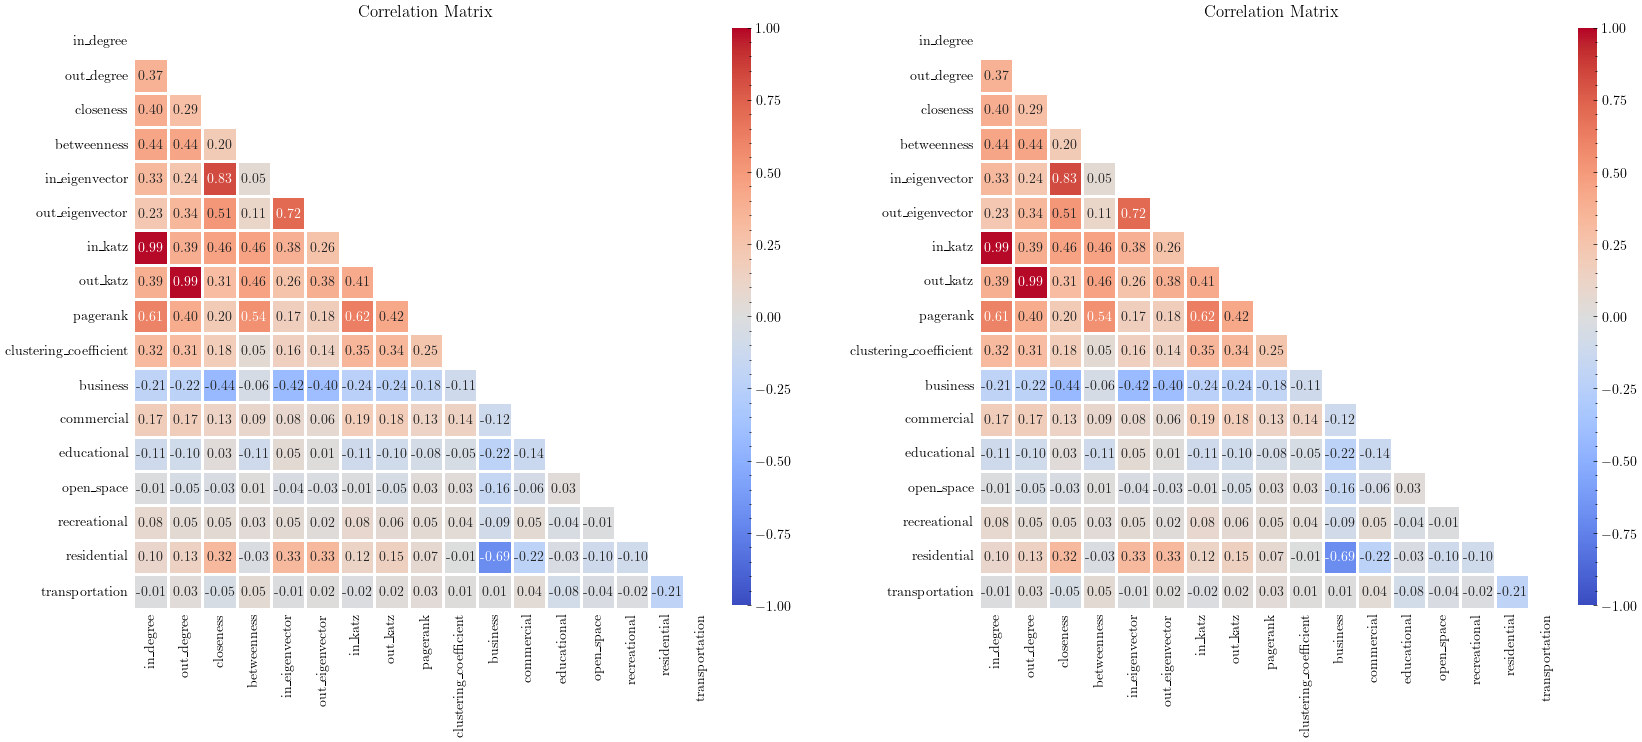

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes = axes.flatten()

ax = axes[0]
plot_correlation_matrix(
    data_l.drop(columns='label'), ax = ax,)
ax = axes[1]
plot_correlation_matrix(
    data_p.drop(columns='label'), ax = ax,)

# 2. Stepwise MNL model

In [6]:
def plot_stepwise_criterion_curve(logs, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    logs = pd.DataFrame(logs).sort_values(by='step')

    ax.plot(logs['step'].values, logs['criterion'].values, marker='o', linestyle='--')
    ax.set_xticks(logs['step'].values)
    ax.set_xticklabels(logs['entered_feature'].values, rotation=90)
    ax.set_xlabel('Entering features')
    ax.set_ylabel('AIC')
    ax.tick_params(which='minor', axis='x', top=False, bottom=False)

    return ax
# ===============================================================
def find_optimal_feature(logs):

    logs = (pd.DataFrame(logs)
        .sort_values(by='step')
        .set_index('step'))

    # Find the step with the minimum criterion value
    min_criterion_idx = logs['criterion'].idxmin()
    feats = logs.loc[:min_criterion_idx, 'entered_feature'].tolist()

    min_criterion     = logs['criterion'].min()
    criterion_val = logs.loc[min_criterion_idx, 'criterion']

    assert min_criterion == criterion_val

    # Resorted to original feature order (excluding 'const')
    feats_sorted = (['const'] +
        [f for f in AAL_COL if f in feats])

    print(
        '\nOptimal criterion value:', criterion_val,
        '\nNumber of feature:', len(feats_sorted) - 1,
        '\nSelected features:', feats_sorted,
    )


Optimal criterion value: 3181.2185914049896 
Number of feature: 8 
Selected features: ['const', 'in_degree', 'out_degree', 'closeness', 'betweenness', 'in_eigenvector', 'out_eigenvector', 'pagerank', 'clustering_coefficient']

Optimal criterion value: 3226.271469881943 
Number of feature: 6 
Selected features: ['const', 'in_degree', 'out_degree', 'betweenness', 'in_eigenvector', 'out_eigenvector', 'clustering_coefficient']

Optimal criterion value: 2139.7511359585906 
Number of feature: 13 
Selected features: ['const', 'in_degree', 'out_degree', 'closeness', 'in_eigenvector', 'out_eigenvector', 'pagerank', 'clustering_coefficient', 'residential', 'business', 'commercial', 'educational', 'open_space', 'transportation']

Optimal criterion value: 2157.983632914874 
Number of feature: 13 
Selected features: ['const', 'in_degree', 'out_degree', 'in_eigenvector', 'out_eigenvector', 'pagerank', 'clustering_coefficient', 'residential', 'business', 'commercial', 'recreational', 'educational', 

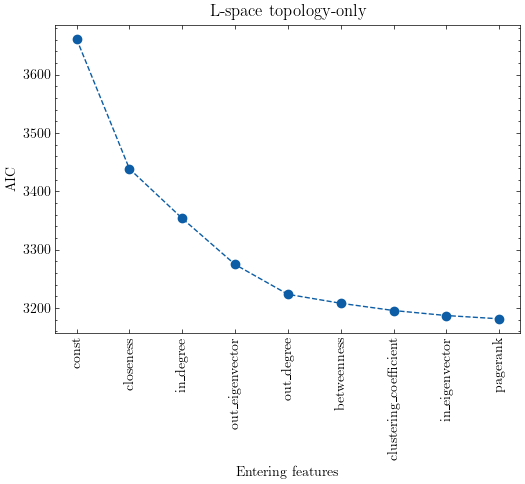

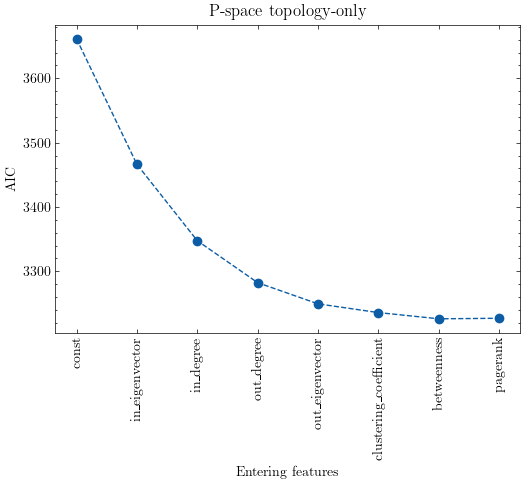

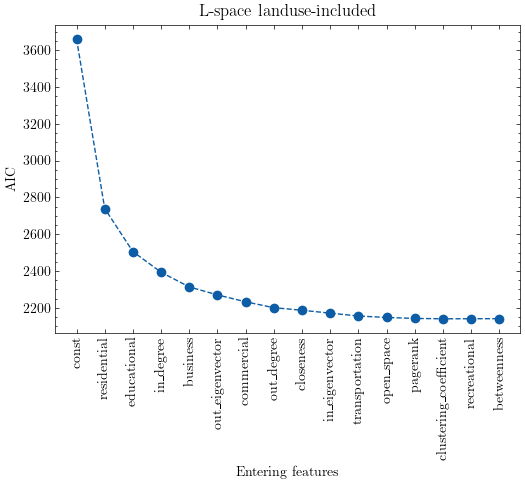

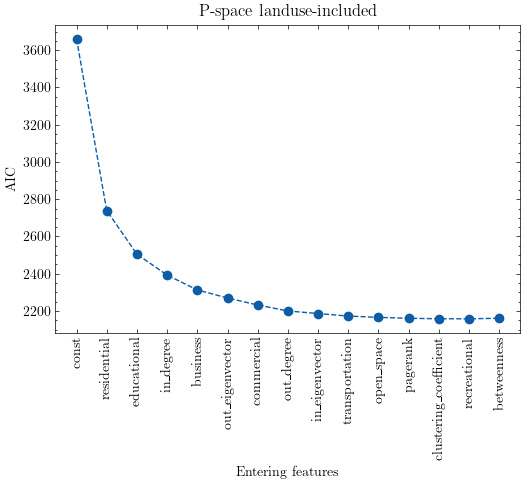

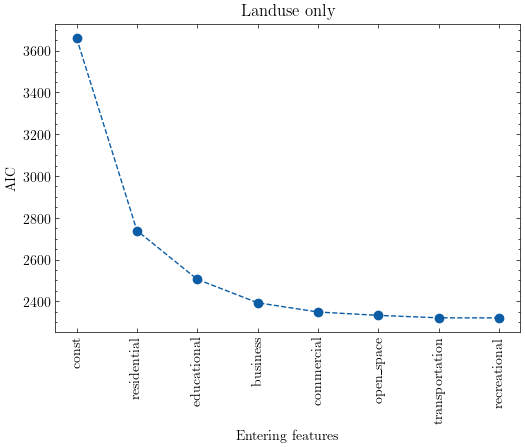

In [7]:
# Model 1: L-space topology-only stepwise MNL
logs = stepwise_MNL(
    Y = data_l['label'].copy(),
    X = data_l[TOPO_L_COL].copy(),
    fit_kwargs = {'maxiter' : 1000, 'disp' : False, 'tol' : 1e-6},
)
ax = plot_stepwise_criterion_curve(logs)
ax.set_title('L-space topology-only')
find_optimal_feature(logs)


# Model 2: P-space topology-only stepwise MNL
logs = stepwise_MNL(
    Y = data_p['label'].copy(),
    X = data_p[TOPO_P_COL].copy(),
    fit_kwargs = {'maxiter' : 1000, 'disp' : False, 'tol' : 1e-6},
)
ax = plot_stepwise_criterion_curve(logs)
ax.set_title('P-space topology-only')
find_optimal_feature(logs)

# Model 3: L-space landus-included stepwise MNL
logs = stepwise_MNL(
    Y = data_l['label'].copy(),
    X = data_l[TOPO_L_COL + LANDUSE_COL].copy(),
    fit_kwargs = {'maxiter' : 1000, 'disp' : False, 'tol' : 1e-6},
)
ax = plot_stepwise_criterion_curve(logs)
ax.set_title('L-space landuse-included')
find_optimal_feature(logs)

# Model 4: P-space landus-included stepwise MNL
logs = stepwise_MNL(
    Y = data_p['label'].copy(),
    X = data_p[TOPO_P_COL + LANDUSE_COL].copy(),
    fit_kwargs = {'maxiter' : 1000, 'disp' : False, 'tol' : 1e-6},
)
ax = plot_stepwise_criterion_curve(logs)
ax.set_title('P-space landuse-included')
find_optimal_feature(logs)

# Model 5: Landuse only stepwise MNL
logs = stepwise_MNL(
    Y = data_l['label'].copy(),
    X = data_l[LANDUSE_COL].copy(),
    fit_kwargs = {'maxiter' : 1000, 'disp' : False, 'tol' : 1e-6},
)
ax = plot_stepwise_criterion_curve(logs)
ax.set_title('Landuse only')
find_optimal_feature(logs)

# 3. Optimal MNL model estimation

In [8]:
# --- Helpers ---
def _significance_star(p: float) -> str:
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""
# ==================================================================================
def format_mnlogit_results(res) -> pd.DataFrame:
    """
    Format a statsmodels MNLogit fitted result into a pandas DataFrame with MultiIndex columns.

    Output columns:
      - 1st level: outcome categories (one column-block per non-baseline category)
      - 2nd level: ["coef", "std_err", "coef_raw", "p_value"]
        where "coef" is rounded and optionally has significance stars appended.

    Significance stars (if stars=True):
      *** : p < 0.01
      **  : p < 0.05
      *   : p < 0.10

    Notes
    -----
    - statsmodels MNLogit uses a baseline (reference) category; it is not included in `res.params`.
    - `res.params` is typically shaped (k_exog, J-1). Columns correspond to non-baseline categories.
    - Row index uses parameter names from `res.params.index` (e.g., "const", feature names).
    """
    # --- Extract core tables (as DataFrames) ---
    params = res.params
    bse    = res.bse
    pvals  = res.pvalues

    # Ensure they are DataFrames (statsmodels usually returns DataFrame, but be defensive)
    if not isinstance(params, pd.DataFrame):
        params = pd.DataFrame(params)
    if not isinstance(bse, pd.DataFrame):
        bse = pd.DataFrame(bse, index=params.index, columns=params.columns)
    if not isinstance(pvals, pd.DataFrame):
        pvals = pd.DataFrame(pvals, index=params.index, columns=params.columns)

    categories = list(params.columns)  # non-baseline outcome categories

    # --- Build blocks per category ---
    blocks = []
    for cat in categories:
        coef_raw = params[cat]
        se = bse[cat]
        pv = pvals[cat]

        # Rounded / starred coefficient as string
        coef_str = coef_raw.round(3).map(lambda v: f"{v:.3f}")
        coef_str = coef_str + pv.map(_significance_star)

        block = pd.DataFrame({
                (cat, "coef")     : coef_str,
                (cat, "std_err")  : se.round(3),
                (cat, "coef_raw") : coef_raw,
                (cat, "p_value")  : pv.round(3),
            },
            index=params.index,
        )
        blocks.append(block)

    out = pd.concat(blocks, axis=1)

    # Make sure columns are a MultiIndex with the requested order on level 2
    out.columns = pd.MultiIndex.from_tuples(out.columns, names=["category", "stat"])

    # Optional: ensure second-level column order within each category
    desired = ["coef", "std_err", "coef_raw", "p_value"]
    out = out.reindex(
        columns=pd.MultiIndex.from_product([categories, desired], names=["category", "stat"])
    )

    return out

In [9]:
# Optimal features
model_feats = {
    # 'L-space topology-only'
    'model1' : [
        'in_degree', 'out_degree', 'closeness', 'betweenness', 'in_eigenvector', 'out_eigenvector', 'pagerank', 'clustering_coefficient'],
    # 'P-space topology-only'
    'model2' : [
        'in_degree', 'out_degree', 'betweenness', 'in_eigenvector', 'out_eigenvector', 'pagerank', 'clustering_coefficient'],
    # 'L-space landuse-included'
    'model3' : [
        'in_degree', 'out_degree', 'closeness', 'in_eigenvector', 'out_eigenvector', 'pagerank', 'clustering_coefficient',
        'residential', 'business', 'commercial', 'educational', 'open_space', 'transportation'],
    # 'P-space landuse-included'
    'model4' : [
        'in_degree', 'out_degree', 'betweenness', 'in_eigenvector', 'out_eigenvector', 'pagerank', 'clustering_coefficient',
        'residential', 'business', 'commercial', 'recreational', 'educational', 'open_space', 'transportation'],
    # 'Landuse only'
    'model5' : [
        'residential', 'business', 'commercial', 'recreational', 'educational', 'open_space', 'transportation'],
}


estimation = {}

for model_name, feat_list in model_feats.items():

    # L-space data
    if model_name in ['model1', 'model3']:
        data = data_l[['label'] + feat_list].copy()
    # P-space data
    elif model_name in ['model2', 'model4']:
        data = data_p[['label'] + feat_list].copy()

    X = sm.add_constant(data[feat_list])
    Y = data['label']

    model = sm.MNLogit(endog=Y, exog=X)
    res = model.fit(
        maxiter = 1000,
        disp = False,
        tol = 1e-6,
    )

    coef = format_mnlogit_results(res)
    # save results
    # coef.to_csv(
    #     PROJECT_PATH / f'results/mnl_model/mnlogit_{model_name}.csv',
    #     index = True, quoting = 2,
    # )